In [68]:
import pandas as pd
from matplotlib import pyplot as plt

# Load data into dataframe
df = pd.read_csv("data/master_cleaned.csv", header=0)
#print(df.head(2)) # Test that the dataframe works

## Story 1: Bitcoin stability compared to memecoin risks

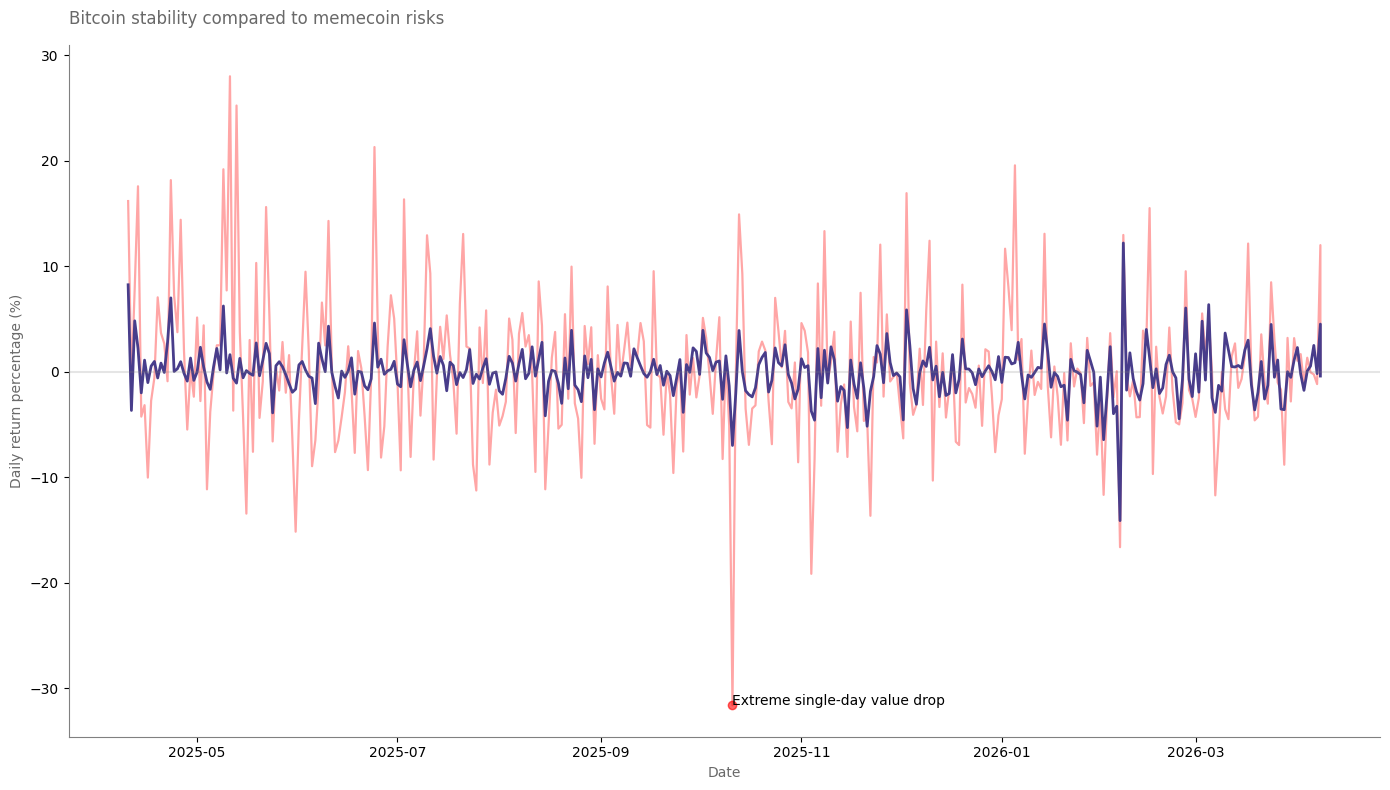

In [69]:
plt.figure(figsize = (14,8))

df["date"] = pd.to_datetime(df["date"])

# Limit dates to only show a year
cutoff = df["date"].max() - pd.Timedelta(days=365)
df = df[df["date"] >= cutoff].copy()

# Pick memecoin and bitcoin for comparison
mcoin = df[df["coin_id"] == "dogwifcoin"]
bcoin = df[df["coin_id"] == "bitcoin"]

plt.plot(mcoin["date"], mcoin["daily_return_pct"], label = "dogwifcoin", linewidth = 1.6, alpha = 0.35, color = "red")
plt.plot(bcoin["date"], bcoin["daily_return_pct"], label = "bitcoin", linewidth = 2, color = "darkslateblue")

ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color("gray")
ax.set_title("Bitcoin stability compared to memecoin risks", loc="left", color = "dimgray", pad = 15)
ax.set_xlabel("Date", color = "dimgray")
ax.set_ylabel("Daily return percentage (%)", color = "dimgray")
plt.axhline(0, color = "gray", alpha = 0.2)

# Find an extremely low value to point out
worst = mcoin.loc[mcoin["daily_return_pct"].idxmin()]
plt.scatter(worst["date"], worst["daily_return_pct"], color = "red", alpha = 0.6)
plt.text(worst["date"], worst["daily_return_pct"], "Extreme single-day value drop", fontsize = 10)

plt.tight_layout()
plt.show()

Bitcoin is shown in blue as a positive coin relative to the chosen memecoin, with clear lines to easily view the more stable daily return percentages.

## Story 2: Lower long term value retention in memecoins vs bitcoin

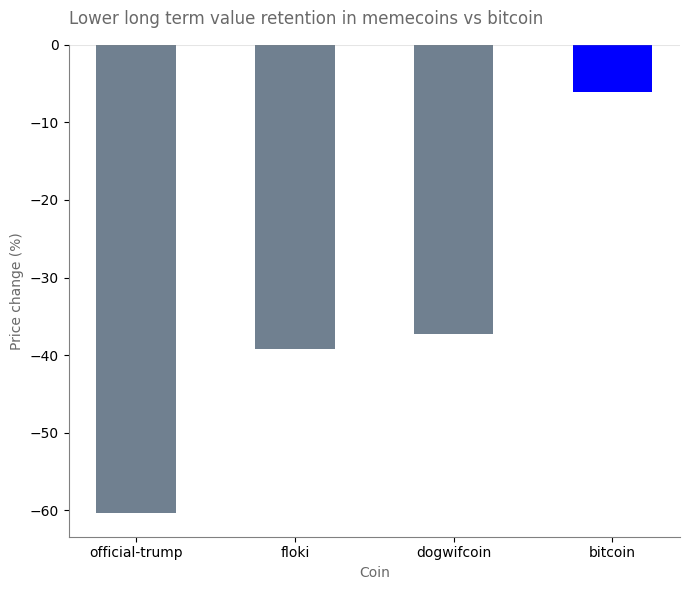

In [70]:
# Summary of first and last price of each coin
summary = df.sort_values(["coin_id", "date"]).groupby("coin_id").agg(
    start_price = ("price", "first"),
    end_price = ("price", "last")
)

# Get % change for prices
summary["pct_change"] = (summary["end_price"] / summary["start_price"] - 1) * 100
summary = summary.sort_values("pct_change")

plt.figure(figsize = (7, 6))
plt.bar(summary.index, summary["pct_change"], width = 0.5 , color = 
        ["slategray" if c != "bitcoin" else "blue" for c in summary.index])

ax = plt.gca()
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color("gray")
ax.set_title("Lower long term value retention in memecoins vs bitcoin", loc="left", color = "dimgray", pad = 15)
ax.set_xlabel("Coin", color = "dimgray")
ax.set_ylabel("Price change (%)", color = "dimgray")
plt.axhline(0, color = "gray", alpha = 0.2)
plt.tight_layout()
plt.show()

Bitcoin showed a relatively small decline (~5%) over the period, while meme coins such as Official Trump experienced much larger losses (~60%), indicating higher downside risk for the meme coins